Predict increase or decrease, predict increase/decrease amount

In [2]:
import pandas as pd
import polars as pl
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential, Model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

SELECTED_FEATURES = ['feature_08', 'feature_26', 'feature_27', 'feature_36', 
                     'feature_58', 'feature_22', 'feature_24', 'feature_01',
                     'feature_09', 'feature_07', 'feature_04']

def create_symbol_dataframes(df: pl.DataFrame, id_col='symbol_id'):
    """Create dictionary of DataFrames grouped by symbol_id"""
    return {
        symbol_id: df.filter(pl.col(id_col) == symbol_id)
        for symbol_id in df[id_col].unique()
    }

def preprocess_and_fill_missing(df: pl.DataFrame, date_col='date_id', time_col='time_id'):
    """Preprocess and fill missing values"""
    df = df.sort(date_col, time_col)
    
    date_dtype = df[date_col].dtype
    time_dtype = df[time_col].dtype
    
    full_index = (
        pl.DataFrame({
            date_col: pl.Series(range(df[date_col].min(), df[date_col].max() + 1)).cast(date_dtype)
        })
        .join(
            pl.DataFrame({
                time_col: pl.Series(range(0, 968)).cast(time_dtype)
            }),
            how="cross"
        )
    )
    
    return (
        full_index.join(df, on=[date_col, time_col], how="left")
        .with_columns([
            pl.col('responder_6')
            .interpolate()
            .fill_null(strategy='forward')
            .fill_null(strategy='backward')
        ])
        .with_columns([
            pl.col(feat)
            .interpolate()
            .fill_null(strategy='forward')
            .fill_null(strategy='backward')
            for feat in SELECTED_FEATURES
        ])
    )

def prepare_data(df_dict, date_col='date_id', val_days=30):
    """Prepare train/validation split while preserving date information"""
    split_data = {}
    
    for symbol, data in df_dict.items():
        max_date = data[date_col].max()
        val_start_date = max_date - val_days
        
        train_data = data.filter(pl.col(date_col) <= val_start_date)
        val_data = data.filter(pl.col(date_col) > val_start_date)
        
        # Keep date_id, responder_6, and selected features
        columns_to_keep = ['date_id', 'responder_6'] + SELECTED_FEATURES
        train_data = train_data.select(columns_to_keep)
        val_data = val_data.select(columns_to_keep)
        
        split_data[symbol] = {
            "Train": train_data,
            "val": val_data
        }
    
    return split_data

def create_day_based_sequences(split_data):
    """Create sequences with both target and feature data"""
    train_set = {}
    val_set = {}

    for symbol_id, data in split_data.items():
        train_data = data["Train"]
        val_data = data["val"]
        
        train_days = (train_data
            .group_by('date_id')
            .agg([
                pl.col('responder_6'),
                *[pl.col(feat) for feat in SELECTED_FEATURES]
            ])
            .sort('date_id'))
        
        train_sequences = []
        train_targets = []
        
        dates = train_days['date_id'].to_list()
        values = train_days['responder_6'].to_list()
        features = {feat: train_days[feat].to_list() for feat in SELECTED_FEATURES}
        
        for i in range(1, len(dates)):
            previous_day_values = values[i - 1]
            current_day_values = values[i]
            current_day_features = [features[feat][i] for feat in SELECTED_FEATURES]
            
            if (len(previous_day_values) == 968 and 
                len(current_day_values) == 968 and 
                all(len(feat) == 968 for feat in current_day_features)):
                
                sequence_data = np.column_stack([
                    previous_day_values,
                    *current_day_feature
                ])
                train_sequences.append(sequence_data)
                train_targets.append(np.array(current_day_values))
        
        if train_sequences:
            train_set[symbol_id] = {
                "X": np.stack(train_sequences),
                "y": np.stack(train_targets)
            }
        
        val_days = (val_data
            .group_by('date_id')
            .agg([
                pl.col('responder_6'),
                *[pl.col(feat) for feat in SELECTED_FEATURES]
            ])
            .sort('date_id'))
        
        val_sequences = []
        val_targets = []
        
        dates = val_days['date_id'].to_list()
        values = val_days['responder_6'].to_list()
        features = {feat: val_days[feat].to_list() for feat in SELECTED_FEATURES}
        
        for i in range(1, len(dates)):
            previous_day_values = values[i - 1]
            current_day_values = values[i]
            current_day_features = [features[feat][i] for feat in SELECTED_FEATURES]
            
            if (len(previous_day_values) == 968 and 
                len(current_day_values) == 968 and 
                all(len(feat) == 968 for feat in current_day_features)):
                
                sequence_data = np.column_stack([
                    previous_day_values,
                    *current_day_features
                ])
                val_sequences.append(sequence_data)
                val_targets.append(np.array(current_day_values))
        
        if val_sequences:
            val_set[symbol_id] = {
                "X": np.stack(val_sequences),
                "y": np.stack(val_targets)
            }

    return train_set, val_set


base_dir = "/kaggle/input/jane-street-real-time-market-data-forecasting/train.parquet/"
partitions = [f"{base_dir}/partition_id={i}/part-0.parquet" for i in range(9, 10)]
columns_to_load = ['date_id', 'time_id', 'symbol_id', 'responder_6'] + SELECTED_FEATURES

train = pl.concat([
    pl.scan_parquet(part)
    .select(columns_to_load)
    .collect() 
    for part in partitions
])

df_lstm = create_symbol_dataframes(train)
for symbol_id in df_lstm.keys():
    df_lstm[symbol_id] = df_lstm[symbol_id].drop('symbol_id')
    df_lstm[symbol_id] = preprocess_and_fill_missing(df_lstm[symbol_id])

split_data = prepare_data(df_lstm)
number_of_lag = 968
n_features = len(SELECTED_FEATURES) + 1  # +1 for responder_6
train_set_lstm, val_set_lstm = create_day_based_sequences(split_data)


In [ ]:
def check_input_differences(train_set_lstm, symbol_id):
    X = train_set_lstm[symbol_id]["X"]
    day_variances = np.var(X, axis=0)
    print(f"Shape of input data: {X.shape}")
    print(f"Mean variance across days: {np.mean(day_variances)}")
    print(f"Max variance across days: {np.max(day_variances)}")

    diff_between_days = np.abs(X[1:] - X[:-1]).mean()
    print(f"Average difference between consecutive days: {diff_between_days}")

    print("\nFirst timestamp values across first 5 days:")
    print(X[:5, 0, :])

check_input_differences(train_set_lstm, list(train_set_lstm.keys())[0])

In [ ]:
sequence_data = np.column_stack([
    previous_day_values,
    *current_day_features
])
print(f"previous_day_values shape: {np.array(previous_day_values).shape}")
print(f"One current_day_feature shape: {np.array(current_day_features[0]).shape}")
print(f"Final sequence_data shape: {sequence_data.shape}")


Training new model for symbol 0
68/69 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1.0283 - mse: 0.7685 - r2_loss: 1.2268
Epoch 1: val_r2_loss improved from inf to 1.09554, saving model to best_model.keras
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 1.0280 - mse: 0.7655 - r2_loss: 1.2246 - val_loss: 1.0040 - val_mse: 0.4929 - val_r2_loss: 1.0955 - learning_rate: 5.0000e-04
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step

Metrics for symbol 0:
MSE: 0.4929
R2 Score: -0.0837


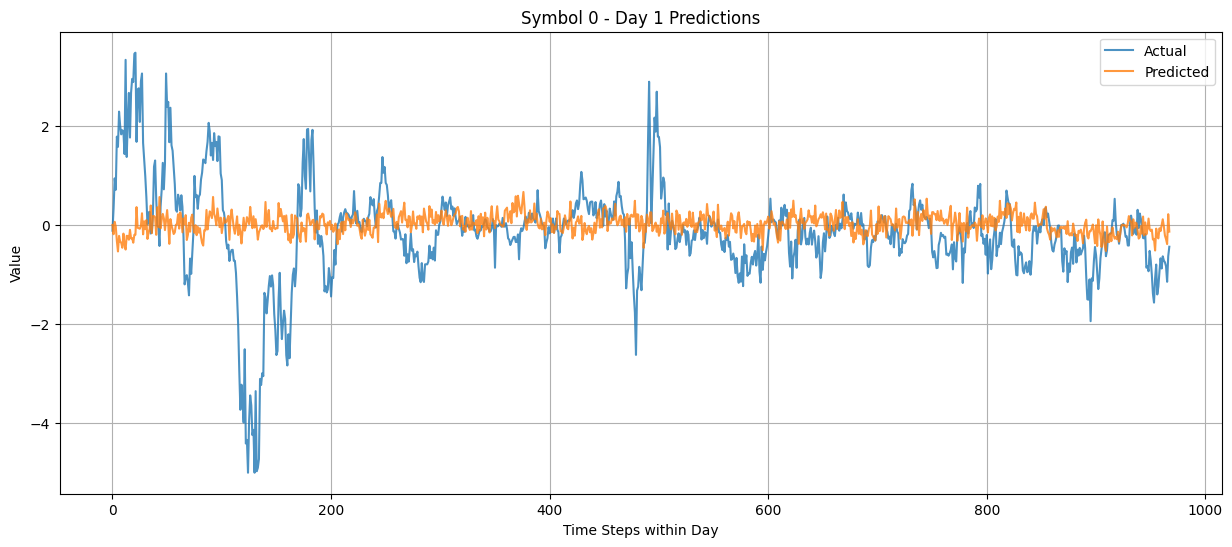

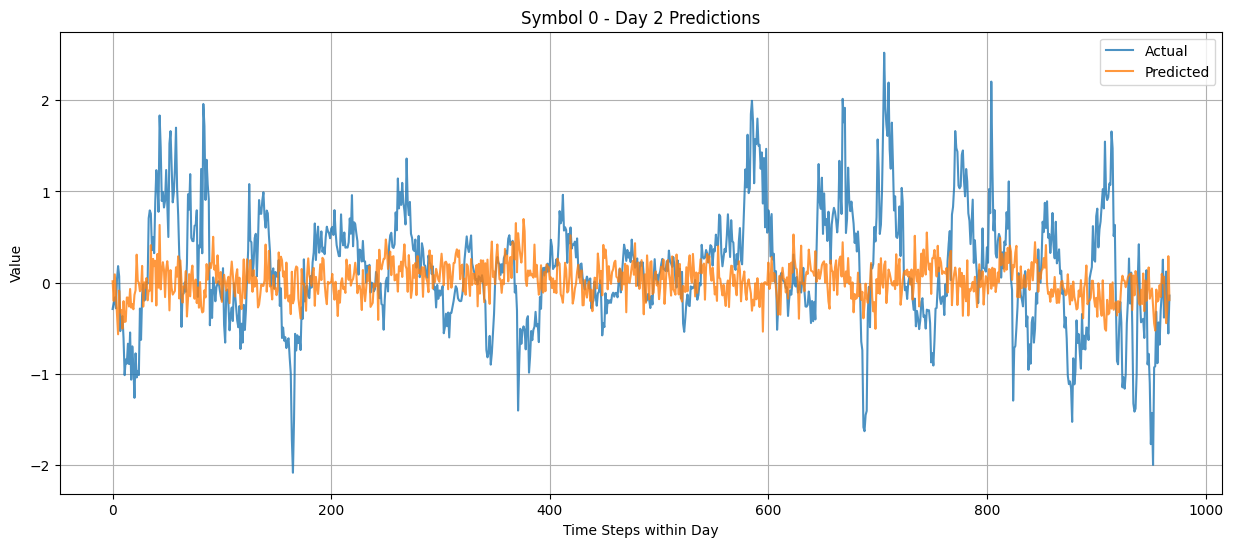


Training new model for symbol 1


KeyboardInterrupt: 

In [20]:
def r2_loss(y_true, y_pred):
    SS_res = tf.reduce_sum(tf.square(y_true - y_pred))
    SS_tot = tf.reduce_sum(tf.square(y_true))
    return SS_res / SS_tot
    
def r2_loss_penalty(y_true, y_pred):
    SS_res = tf.reduce_sum(tf.square(y_true - y_pred))
    SS_tot = tf.reduce_sum(tf.square(y_true))
    return SS_res / SS_tot - 0.9*tf.reduce_sum(tf.square(y_pred))/SS_tot

def r2_mse_loss_penalty(y_true, y_pred):
    SS_res = tf.reduce_sum(tf.square(y_true - y_pred))
    SS_tot = tf.reduce_sum(tf.square(y_true))
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    return SS_res / SS_tot - 1.4*tf.reduce_sum(tf.square(y_pred))/SS_tot + mse

def mse_loss_penalty(y_true, y_pred):
    SS_tot = tf.reduce_sum(tf.square(y_true))
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    return - 0.4*tf.reduce_sum(tf.square(y_pred))/SS_tot + mse

def create_enhanced_lstm_model(number_of_lag, n_features):
    """
    Creates an improved LSTM model with fixes for:
    1. Softmax warning by removing problematic attention
    2. Prediction range compression
    3. Negative loss issues
    """
    inputs = Input(shape=(number_of_lag, n_features))

    x = LayerNormalization()(inputs)

    lstm1 = LSTM(512, return_sequences=True, 
                 kernel_initializer='he_normal',
                 recurrent_initializer='orthogonal')(x)
    lstm1 = LayerNormalization()(lstm1)
    lstm1 = Dropout(0.1)(lstm1)
    residual1 = Conv1D(512, 1, kernel_initializer='he_normal')(x)
    x = Add()([lstm1, residual1])

    lstm2 = LSTM(512, return_sequences=True,
                 kernel_initializer='he_normal',
                 recurrent_initializer='orthogonal')(x)
    lstm2 = LayerNormalization()(lstm2)
    lstm2 = Dropout(0.1)(lstm2)
    
    attention_scores = Dense(1, use_bias=False)(lstm2)
    attention_weights = Activation('sigmoid')(attention_scores)
    x = Multiply()([lstm2, attention_weights])

    x = GlobalAveragePooling1D()(x)

    x = Dense(512, kernel_initializer='he_normal')(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = LayerNormalization()(x)
    x = Dropout(0.2)(x)
    
    x = Dense(512, kernel_initializer='he_normal')(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = LayerNormalization()(x)
    x = Dropout(0.2)(x)

    x = Dense(968, kernel_initializer='he_normal')(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = LayerNormalization()(x)
    
    outputs = Dense(968, kernel_initializer='glorot_normal')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=0.001,
        weight_decay=1e-5,
        clipnorm=1.0,
        epsilon=1e-7
    )    

    model.compile(
        optimizer=optimizer,
        loss=r2_loss_penalty,
        metrics=[r2_loss, 'mse']
    )
    
    return model


def train_model(model, train_data, val_data):
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_r2_loss', mode='min',
            patience=15,
            restore_best_weights=False,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_r2_loss', mode='min',
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            'best_model.keras',
            monitor='val_r2_loss', mode='min',
            save_best_only=True,
            verbose=1
        )
    ]

    
    history = model.fit(
        train_data["X"],
        train_data["y"],
        epochs=1,
        batch_size=2,
        validation_data=(val_data["X"], val_data["y"]),
        callbacks=callbacks,
        verbose=1
    )
    return history
    
models = {}
histories = {}
for symbol_id in train_set_lstm:
    print(f"\nTraining new model for symbol {symbol_id}")
    
    models[symbol_id] = create_enhanced_lstm_model(number_of_lag, n_features)
    
    histories[symbol_id] = train_model(
        models[symbol_id], 
        train_set_lstm[symbol_id], 
        val_set_lstm[symbol_id]
    )
    
    pred = models[symbol_id].predict(val_set_lstm[symbol_id]["X"])
    
    mse = mean_squared_error(val_set_lstm[symbol_id]["y"].flatten(), pred.flatten())
    r2 = r2_score(val_set_lstm[symbol_id]["y"].flatten(), pred.flatten())
    print(f"\nMetrics for symbol {symbol_id}:")
    print(f"MSE: {mse:.4f}")
    print(f"R2 Score: {r2:.4f}")

    models[symbol_id].save(f'lstm_model_symbol_{symbol_id}.keras')
    
    for day in range(2):
        plt.figure(figsize=(15, 6))
        plt.plot(val_set_lstm[symbol_id]["y"][day], label='Actual', alpha=0.8)
        plt.plot(pred[day], label='Predicted', alpha=0.8)
        plt.title(f'Symbol {symbol_id} - Day {day+1} Predictions')
        plt.xlabel('Time Steps within Day')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True)
        plt.show()